## Iterative Training and Screening with Li-Air Models

This notebook trains NGBoost regressors with Normal predictive
distributions using Li-air datasets from iterations 1–6.
Inputs are `CurrentDensity`, `O2`, and `CO2`.

### Workflow

1. Independently split each dataset by compound, reserving 25%
   of compound groups for testing.
2. Perform five-fold grouped cross-validation within each training
   set and evaluate R², MAE, and RMSE.
3. Save trained models, scatter data, and cross-validation results.


In [1]:
# ============================================================
# 1. Import libraries
# ============================================================

from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ngboost import NGBRegressor
from ngboost.distns import Normal

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    cross_validate
)

In [2]:
# ============================================================
# 2. Configuration
# ============================================================

DATA_PATHS = {
    "Iteration_1": Path("data/1_air.xlsx"),
    "Iteration_2": Path("data/2_air.xlsx"),
    "Iteration_3": Path("data/3_air.xlsx"),
    "Iteration_4": Path("data/4_air.xlsx"),
    "Iteration_5": Path("data/5_air.xlsx"),
    "Iteration_6": Path("data/6_air.xlsx")
}

SHEET_NAME = "Sheet1"

GROUP_COL = "compounds"

FEATURE_COLS = [
    "CurrentDensity",
    "O2",
    "CO2"
]

TARGET_COL = "overpotential"

RANDOM_STATE = 42
TEST_SIZE = 0.25
N_SPLITS = 5


# Output directories
MODEL_DIR = Path("model")
RESULT_DIR = Path("results")

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# MODEL_PATH = (
#     MODEL_DIR
#     / f"ngboost_air_{iteration_number}.pkl"
# )

# SCATTER_PATH = (
#     RESULT_DIR
#     / f"ngboost_air_scatter_data_{iteration_number}.xlsx"
# )

# CV_PATH = (
#     RESULT_DIR
#     / f"ngboost_air_cv_results_{iteration_number}.xlsx"
# )

In [3]:
# ============================================================
# 3. Load data
# ============================================================

iteration_data = {}


for iteration_name, data_path in DATA_PATHS.items():

    data = pd.read_excel(
        data_path,
        sheet_name=SHEET_NAME
    )

    model_data = data[
        [
            GROUP_COL,
            *FEATURE_COLS,
            TARGET_COL
        ]
    ].dropna().copy()

    X = model_data[
        FEATURE_COLS
    ].copy()

    y = model_data[
        TARGET_COL
    ].copy()

    groups = model_data[
        GROUP_COL
    ].astype(str).copy()


    # Store the current iteration data
    iteration_data[iteration_name] = {
        "data_path": data_path,
        "model_data": model_data,
        "X": X,
        "y": y,
        "groups": groups
    }


    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print(
        f"Samples: {len(model_data)}"
    )

    print(
        f"Compounds: {groups.nunique()}"
    )


Iteration_1
Samples: 114
Compounds: 19

Iteration_2
Samples: 213
Compounds: 36

Iteration_3
Samples: 270
Compounds: 46

Iteration_4
Samples: 318
Compounds: 54

Iteration_5
Samples: 432
Compounds: 73

Iteration_6
Samples: 499
Compounds: 85


In [4]:
# ============================================================
# 4. Train-test split
# ============================================================

for iteration_name, iteration in iteration_data.items():

    X = iteration["X"]
    y = iteration["y"]
    groups = iteration["groups"]


    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    train_idx, test_idx = next(
        splitter.split(
            X,
            y,
            groups=groups
        )
    )


    X_train = X.iloc[
        train_idx
    ].reset_index(drop=True)

    X_test = X.iloc[
        test_idx
    ].reset_index(drop=True)

    y_train = y.iloc[
        train_idx
    ].reset_index(drop=True)

    y_test = y.iloc[
        test_idx
    ].reset_index(drop=True)

    groups_train = groups.iloc[
        train_idx
    ].reset_index(drop=True)

    groups_test = groups.iloc[
        test_idx
    ].reset_index(drop=True)


    # Check compound overlap
    overlap = (
        set(groups_train)
        & set(groups_test)
    )

    assert len(overlap) == 0


    # Store train-test split
    iteration["X_train"] = X_train
    iteration["X_test"] = X_test

    iteration["y_train"] = y_train
    iteration["y_test"] = y_test

    iteration["groups_train"] = (
        groups_train
    )

    iteration["groups_test"] = (
        groups_test
    )


    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print(
        f"Training samples: {len(X_train)}"
    )

    print(
        f"Test samples: {len(X_test)}"
    )

    print(
        f"Training compounds: "
        f"{groups_train.nunique()}"
    )

    print(
        f"Test compounds: "
        f"{groups_test.nunique()}"
    )


Iteration_1
Training samples: 84
Test samples: 30
Training compounds: 14
Test compounds: 5

Iteration_2
Training samples: 159
Test samples: 54
Training compounds: 27
Test compounds: 9

Iteration_3
Training samples: 201
Test samples: 69
Training compounds: 34
Test compounds: 12

Iteration_4
Training samples: 237
Test samples: 81
Training compounds: 40
Test compounds: 14

Iteration_5
Training samples: 320
Test samples: 112
Training compounds: 54
Test compounds: 19

Iteration_6
Training samples: 377
Test samples: 122
Training compounds: 63
Test compounds: 22


In [5]:
# ============================================================
# 5. Define model
# ============================================================

def create_model():

    return NGBRegressor(
        Dist=Normal,
        n_estimators=300,
        learning_rate=0.03,
        minibatch_frac=0.8,
        col_sample=1.0,
        random_state=RANDOM_STATE,
        verbose=False
    )


# ============================================================
# Metric function
# ============================================================

def calculate_metrics(
    y_true,
    y_pred
):

    return {
        "R2": r2_score(
            y_true,
            y_pred
        ),
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        )
    }

In [6]:
# ============================================================
# 6. Cross-validation, model training, and evaluation
# ============================================================

scoring = {
    "R2": "r2",
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error"
}


# Store results from all iterations
all_metrics = []
all_cv_summary = []


for iteration_name, iteration in iteration_data.items():

    X_train = iteration["X_train"]
    X_test = iteration["X_test"]

    y_train = iteration["y_train"]
    y_test = iteration["y_test"]

    groups_train = iteration["groups_train"]


    # Create a new model for each iteration
    model = create_model()


    # --------------------------------------------------------
    # Group cross-validation
    # --------------------------------------------------------

    group_cv = GroupKFold(
        n_splits=N_SPLITS
    )

    cv_scores = cross_validate(
        model,
        X_train,
        y_train,
        groups=groups_train,
        cv=group_cv,
        scoring=scoring
    )

    cv_results = pd.DataFrame({
        "Fold": np.arange(
            1,
            N_SPLITS + 1
        ),
        "R2": cv_scores["test_R2"],
        "MAE": -cv_scores["test_MAE"],
        "RMSE": -cv_scores["test_RMSE"]
    })


    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("\nCross-validation results")
    print(
        cv_results.to_string(
            index=False
        )
    )

    print("\nCross-validation summary")


    cv_summary = {}

    for metric in [
        "R2",
        "MAE",
        "RMSE"
    ]:

        mean_value = cv_results[
            metric
        ].mean()

        std_value = cv_results[
            metric
        ].std(ddof=1)

        cv_summary[
            f"CV_{metric}_Mean"
        ] = mean_value

        cv_summary[
            f"CV_{metric}_Std"
        ] = std_value

        print(
            f"CV {metric}: "
            f"{mean_value:.6f} +/- "
            f"{std_value:.6f}"
        )


    # --------------------------------------------------------
    # Train the model
    # --------------------------------------------------------

    model.fit(
        X_train,
        y_train
    )


    train_prediction = model.predict(
        X_train
    )

    test_prediction = model.predict(
        X_test
    )


    # --------------------------------------------------------
    # Calculate metrics
    # --------------------------------------------------------

    train_metrics = calculate_metrics(
        y_train,
        train_prediction
    )

    test_metrics = calculate_metrics(
        y_test,
        test_prediction
    )


    print("\nTraining results")

    print(
        f"R2:   {train_metrics['R2']:.6f}"
    )

    print(
        f"MAE:  {train_metrics['MAE']:.6f}"
    )

    print(
        f"RMSE: {train_metrics['RMSE']:.6f}"
    )


    print("\nTest results")

    print(
        f"R2:   {test_metrics['R2']:.6f}"
    )

    print(
        f"MAE:  {test_metrics['MAE']:.6f}"
    )

    print(
        f"RMSE: {test_metrics['RMSE']:.6f}"
    )


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    iteration["model"] = model
    iteration["cv_results"] = cv_results

    iteration["train_prediction"] = (
        train_prediction
    )

    iteration["test_prediction"] = (
        test_prediction
    )

    iteration["train_metrics"] = (
        train_metrics
    )

    iteration["test_metrics"] = (
        test_metrics
    )

    iteration["cv_summary"] = (
        cv_summary
    )


    # Store cross-validation summary
    all_cv_summary.append({
        "Iteration": iteration_name,
        **cv_summary
    })


    # Store training metrics
    all_metrics.append({
        "Iteration": iteration_name,
        "Dataset": "Train",
        "Sample_Size": len(y_train),
        **train_metrics
    })


    # Store test metrics
    all_metrics.append({
        "Iteration": iteration_name,
        "Dataset": "Test",
        "Sample_Size": len(y_test),
        **test_metrics
    })


Iteration_1

Cross-validation results
 Fold        R2      MAE     RMSE
    1  0.598459 0.087408 0.109789
    2 -0.117157 0.114290 0.151467
    3  0.458844 0.118835 0.216307
    4  0.296479 0.099211 0.130450
    5  0.174356 0.104448 0.118905

Cross-validation summary
CV R2: 0.282196 +/- 0.275020
CV MAE: 0.104839 +/- 0.012459
CV RMSE: 0.145384 +/- 0.042598

Training results
R2:   0.990266
MAE:  0.016372
RMSE: 0.019137

Test results
R2:   0.725591
MAE:  0.050481
RMSE: 0.071329

Iteration_2

Cross-validation results
 Fold       R2      MAE     RMSE
    1 0.556806 0.115284 0.164745
    2 0.459955 0.098790 0.165567
    3 0.411741 0.080305 0.168649
    4 0.412667 0.103240 0.142036
    5 0.320940 0.089236 0.140466

Cross-validation summary
CV R2: 0.432422 +/- 0.085843
CV MAE: 0.097371 +/- 0.013368
CV RMSE: 0.156293 +/- 0.013819

Training results
R2:   0.963572
MAE:  0.033024
RMSE: 0.041329

Test results
R2:   0.727677
MAE:  0.095111
RMSE: 0.122420

Iteration_3

Cross-validation results
 Fold

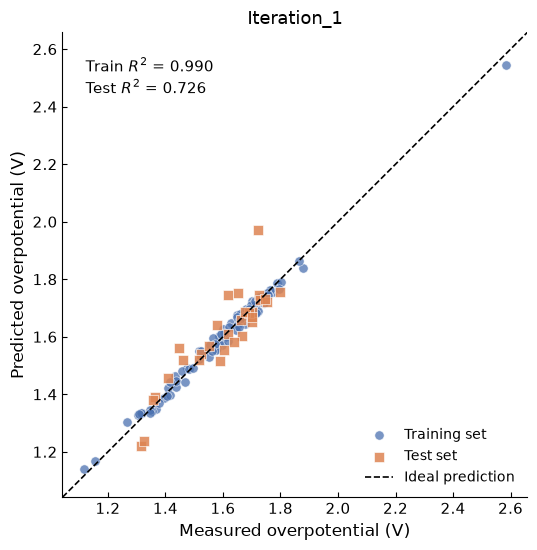

Iteration_1 scatter data saved to: results\ngboost_air_scatter_data_1.xlsx
Iteration_1 cross-validation results saved to: results\ngboost_air_cv_results_1.xlsx


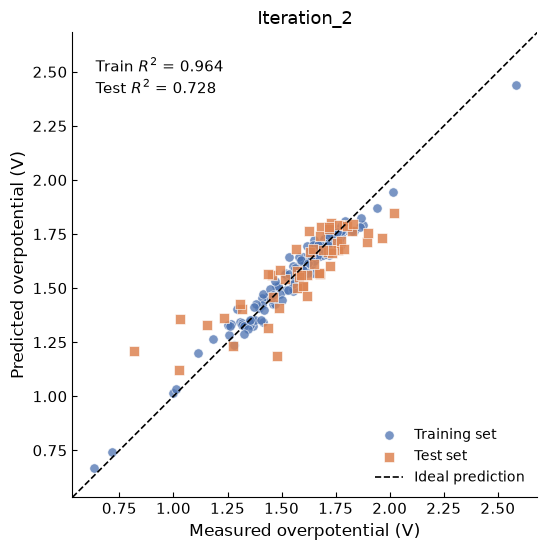

Iteration_2 scatter data saved to: results\ngboost_air_scatter_data_2.xlsx
Iteration_2 cross-validation results saved to: results\ngboost_air_cv_results_2.xlsx


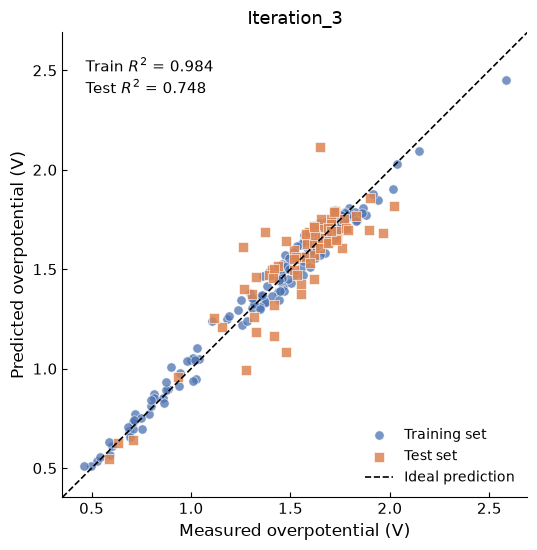

Iteration_3 scatter data saved to: results\ngboost_air_scatter_data_3.xlsx
Iteration_3 cross-validation results saved to: results\ngboost_air_cv_results_3.xlsx


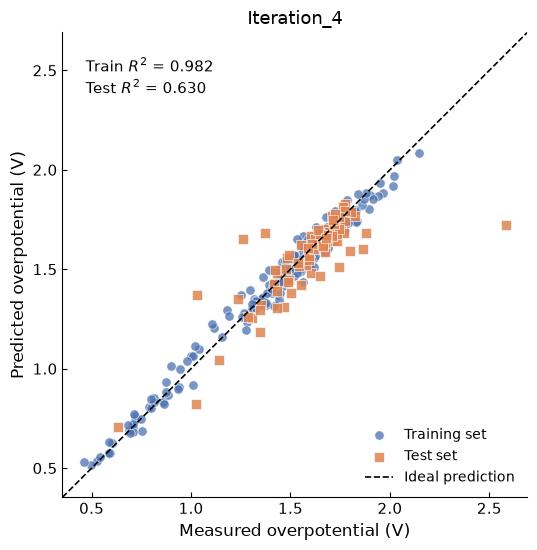

Iteration_4 scatter data saved to: results\ngboost_air_scatter_data_4.xlsx
Iteration_4 cross-validation results saved to: results\ngboost_air_cv_results_4.xlsx


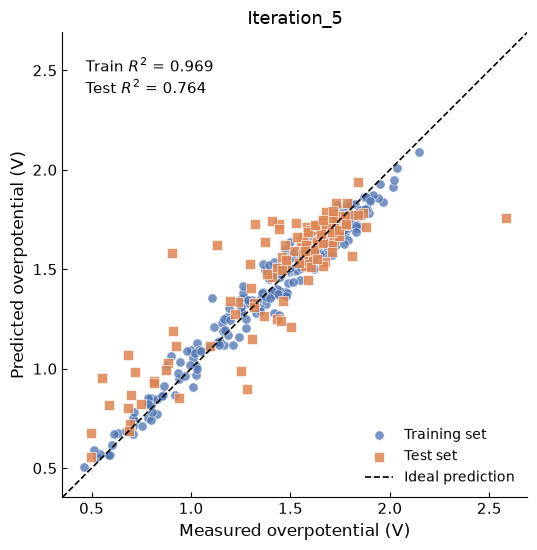

Iteration_5 scatter data saved to: results\ngboost_air_scatter_data_5.xlsx
Iteration_5 cross-validation results saved to: results\ngboost_air_cv_results_5.xlsx


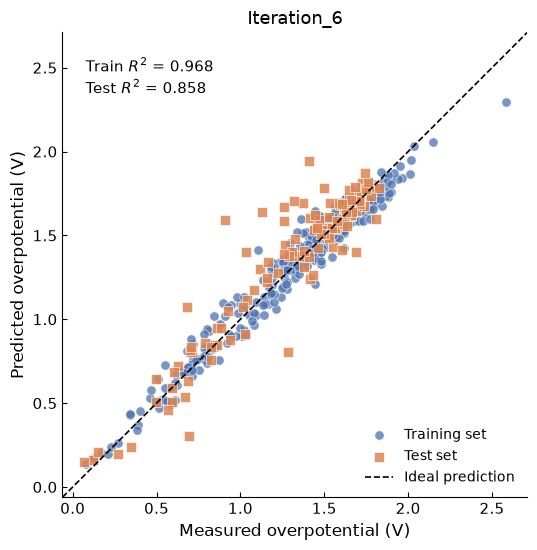

Iteration_6 scatter data saved to: results\ngboost_air_scatter_data_6.xlsx
Iteration_6 cross-validation results saved to: results\ngboost_air_cv_results_6.xlsx


In [7]:
# ============================================================
# 7. Plot and save scatter data
# ============================================================

for iteration_name, iteration in iteration_data.items():

    iteration_number = (
        iteration_name.split("_")[-1]
    )

    y_train = iteration["y_train"]
    y_test = iteration["y_test"]

    train_prediction = (
        iteration["train_prediction"]
    )

    test_prediction = (
        iteration["test_prediction"]
    )

    train_metrics = (
        iteration["train_metrics"]
    )

    test_metrics = (
        iteration["test_metrics"]
    )

    cv_results = (
        iteration["cv_results"]
    )


    # Output paths
    SCATTER_PATH = (
        RESULT_DIR
        / f"ngboost_air_scatter_data_{iteration_number}.xlsx"
    )

    CV_PATH = (
        RESULT_DIR
        / f"ngboost_air_cv_results_{iteration_number}.xlsx"
    )


    # Create scatter data
    scatter_data = pd.DataFrame({
        "Train_Measured": pd.Series(
            y_train.to_numpy()
        ),
        "Train_Predicted": pd.Series(
            train_prediction
        ),
        "Test_Measured": pd.Series(
            y_test.to_numpy()
        ),
        "Test_Predicted": pd.Series(
            test_prediction
        )
    })


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(6.2, 5.6)
    )

    ax.scatter(
        scatter_data["Train_Measured"],
        scatter_data["Train_Predicted"],
        s=45,
        color="#4C72B0",
        alpha=0.75,
        edgecolor="white",
        linewidth=0.5,
        label="Training set"
    )

    ax.scatter(
        scatter_data["Test_Measured"],
        scatter_data["Test_Predicted"],
        s=55,
        color="#DD8452",
        alpha=0.85,
        marker="s",
        edgecolor="white",
        linewidth=0.5,
        label="Test set"
    )


    all_measured = np.concatenate([
        y_train.to_numpy(),
        y_test.to_numpy()
    ])

    all_predicted = np.concatenate([
        np.asarray(train_prediction),
        np.asarray(test_prediction)
    ])


    axis_min = min(
        all_measured.min(),
        all_predicted.min()
    )

    axis_max = max(
        all_measured.max(),
        all_predicted.max()
    )

    axis_range = axis_max - axis_min

    padding = (
        axis_range * 0.05
        if axis_range > 0
        else 0.1
    )

    plot_limits = [
        axis_min - padding,
        axis_max + padding
    ]


    ax.plot(
        plot_limits,
        plot_limits,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label="Ideal prediction"
    )

    ax.set_xlim(plot_limits)
    ax.set_ylim(plot_limits)

    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    ax.set_xlabel(
        "Measured overpotential (V)",
        fontsize=12
    )

    ax.set_ylabel(
        "Predicted overpotential (V)",
        fontsize=12
    )

    ax.set_title(
        iteration_name,
        fontsize=13
    )


    metric_text = (
        f"Train $R^2$ = "
        f"{train_metrics['R2']:.3f}\n"
        f"Test $R^2$ = "
        f"{test_metrics['R2']:.3f}"
    )

    ax.text(
        0.05,
        0.95,
        metric_text,
        transform=ax.transAxes,
        verticalalignment="top",
        fontsize=11
    )

    ax.legend(
        frameon=False,
        loc="lower right"
    )

    ax.tick_params(
        direction="in",
        labelsize=11
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()

    plt.show()


    # --------------------------------------------------------
    # Save results
    # --------------------------------------------------------

    scatter_data.to_excel(
        SCATTER_PATH,
        index=False
    )

    cv_results.to_excel(
        CV_PATH,
        index=False
    )


    # Store scatter data and paths
    iteration["scatter_data"] = (
        scatter_data
    )

    iteration["scatter_path"] = (
        SCATTER_PATH
    )

    iteration["cv_path"] = (
        CV_PATH
    )


    print(
        f"{iteration_name} scatter data saved to: "
        f"{SCATTER_PATH}"
    )

    print(
        f"{iteration_name} cross-validation results saved to: "
        f"{CV_PATH}"
    )

In [8]:
# ============================================================
# 8. Save models and summarize CV results
# ============================================================

for iteration_name, iteration in iteration_data.items():

    iteration_number = (
        iteration_name.split("_")[-1]
    )

    model = iteration["model"]

    MODEL_PATH = (
        MODEL_DIR
        / f"ngboost_air_{iteration_number}.pkl"
    )

    joblib.dump(
        model,
        MODEL_PATH
    )

    iteration["model_path"] = (
        MODEL_PATH
    )

    print(
        f"{iteration_name} model saved to: "
        f"{MODEL_PATH}"
    )


# ============================================================
# Summarize cross-validation results
# ============================================================

cv_summary_table = pd.DataFrame(
    all_cv_summary
)

CV_SUMMARY_PATH = (
    RESULT_DIR
    / "ngboost_air_iteration_cv_summary.xlsx"
)

cv_summary_table.to_excel(
    CV_SUMMARY_PATH,
    index=False
)


print("\n" + "=" * 70)
print("Cross-validation performance comparison")
print("=" * 70)

print(
    cv_summary_table.round(4)
)

print(
    f"\nCV summary saved to: "
    f"{CV_SUMMARY_PATH}"
)

Iteration_1 model saved to: model\ngboost_air_1.pkl
Iteration_2 model saved to: model\ngboost_air_2.pkl
Iteration_3 model saved to: model\ngboost_air_3.pkl
Iteration_4 model saved to: model\ngboost_air_4.pkl
Iteration_5 model saved to: model\ngboost_air_5.pkl
Iteration_6 model saved to: model\ngboost_air_6.pkl

Cross-validation performance comparison
     Iteration  CV_R2_Mean  CV_R2_Std  CV_MAE_Mean  CV_MAE_Std  CV_RMSE_Mean  \
0  Iteration_1      0.2822     0.2750       0.1048      0.0125        0.1454   
1  Iteration_2      0.4324     0.0858       0.0974      0.0134        0.1563   
2  Iteration_3      0.5829     0.5304       0.1143      0.0310        0.1790   
3  Iteration_4      0.7566     0.1721       0.1019      0.0229        0.1525   
4  Iteration_5      0.7838     0.0598       0.1012      0.0231        0.1517   
5  Iteration_6      0.8252     0.0412       0.1217      0.0250        0.1732   

   CV_RMSE_Std  
0       0.0426  
1       0.0138  
2       0.0501  
3       0.0400  
4